# Gulf - Matchup Analysis #

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.stats as stats

In [29]:
df1 = pd.read_csv("/home/jovyan/2026-proj-hypoxia-zones/data/sat_matchups/Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.csv")
df1['datetime'] = pd.to_datetime(df1['DATE'].astype(str) + ' ' + df1['TIME'].astype(str))
rrs_cols1 = [c for c in df1.columns if 'PRrs' in c]
df1=df1[['datetime','longitude', 'latitude', 'oxygen']+rrs_cols1]
df1['source']='NOAA Hypoxia'

#add in LSU data and reformat to match noaa to concat 
df2 = pd.read_csv("/home/jovyan/2026-proj-hypoxia-zones/data/sat_matchups/Unique_PACE_matchups_LSU_Hypoxia_2024_2025.csv")
df2['datetime'] = pd.to_datetime(df2['lsu_Date'].astype(str) + ' ' + df2['lsu_Time.CTD.Cast.began..UTC.'].astype(str))
rrs_cols2 = [c for c in df2.columns if 'PRrs' in c]
df2 = df2.rename(columns={"lsu_Corrected.DO..mg.L.": "oxygen"}).reset_index(drop=True)
df2=df2[['datetime','longitude', 'latitude', 'oxygen']+rrs_cols2]
df2['source']='LSU'

matchup_df = pd.concat([df1, df2], axis=0).reset_index(drop=True)

/tmp/ipykernel_835/2303728751.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['datetime'] = pd.to_datetime(df1['DATE'].astype(str) + ' ' + df1['TIME'].astype(str))


In [30]:
os.getcwd()

'/home/jovyan/2026-proj-hypoxia-zones/contributor_folders/stormheidinger'

In [31]:
#matchup_df = pd.read_csv("/home/jovyan/2026-proj-hypoxia-zones/data/sat_matchups/Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.csv")

In [32]:
matchup_df

,datetime,longitude,latitude,oxygen,PRrs346,PRrs348,PRrs351,PRrs353,PRrs356,PRrs358,...,PRrs707,PRrs708,PRrs709,PRrs711,PRrs712,PRrs713,PRrs714,PRrs717,PRrs719,source
0,2024-06-04 18:20:56,-89.996833,28.501333,4.0673,0.010442,0.010546,0.011008,0.011301,0.011510,0.011829,...,0.000020,0.000015,0.000010,0.000025,0.000020,-0.000011,-0.000029,0.000016,0.000164,NOAA Hypoxia
1,2024-06-04 18:20:56,-89.996833,28.501333,4.0673,0.006290,0.006804,0.006942,0.006848,0.007116,0.007610,...,-0.000002,0.000000,-0.000016,-0.000008,-0.000008,-0.000014,-0.000032,-0.000040,0.000004,NOAA Hypoxia
2,2024-06-04 18:20:56,-89.996833,28.501333,4.0673,0.008922,0.008710,0.008614,0.008600,0.008378,0.008748,...,-0.000064,-0.000096,-0.000102,-0.000108,-0.000118,-0.000134,-0.000122,-0.000004,0.000208,NOAA Hypoxia
3,2024-06-04 18:20:56,-89.996833,28.501333,4.0673,0.005516,0.005528,0.005728,0.005878,0.006046,0.006198,...,0.000104,0.000088,0.000088,0.000104,0.000096,0.000090,0.000070,0.000074,0.000118,NOAA Hypoxia
4,2024-06-04 21:53:52,-90.121500,28.363000,4.4879,0.009786,0.010448,0.010792,0.011204,0.011632,0.011752,...,0.000092,0.000088,0.000070,0.000070,0.000058,0.000000,-0.000020,0.000062,0.000332,NOAA Hypoxia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864,2024-07-23 03:09:00,-90.488300,28.915000,0.5800,0.000122,0.000166,0.000256,0.000277,0.000348,0.000509,...,0.000468,0.000433,0.000420,0.000397,0.000380,0.000360,0.000323,0.000349,0.000464,LSU
865,2024-07-23 02:22:00,-90.491500,28.869700,2.3500,-0.000413,-0.000394,-0.000300,-0.000439,-0.000343,-0.000139,...,0.000335,0.000316,0.000300,0.000287,0.000284,0.000272,0.000266,0.000317,0.000402,LSU
866,2024-07-23 01:17:00,-90.390200,28.831500,3.3100,0.000248,0.000269,0.000318,0.000359,0.000247,0.000314,...,0.000262,0.000246,0.000232,0.000225,0.000203,0.000193,0.000174,0.000241,0.000325,LSU
867,2024-07-23 19:03:00,-90.833500,28.715700,0.7400,0.000350,0.000418,0.000730,0.000766,0.000662,0.000962,...,0.001648,0.001644,0.001644,0.001636,0.001636,0.001626,0.001590,0.001572,0.001584,LSU


In [48]:
rrs_col = matchup_df.columns[4:176]
rrs_col

Index(['PRrs346', 'PRrs348', 'PRrs351', 'PRrs353', 'PRrs356', 'PRrs358',
       'PRrs361', 'PRrs363', 'PRrs366', 'PRrs368',
       ...
       'PRrs706', 'PRrs707', 'PRrs708', 'PRrs709', 'PRrs711', 'PRrs712',
       'PRrs713', 'PRrs714', 'PRrs717', 'PRrs719'],
      dtype='object', length=172)

In [64]:
hypoxic_threshold = 2
matchup_df_hypoxic = matchup_df[matchup_df['oxygen']<=hypoxic_threshold]
matchup_df_oxic = matchup_df[matchup_df['oxygen']>hypoxic_threshold]

In [65]:
def plot_rrs_validation(df,rrs_col_name,var_name,plot_name):

    x=df[rrs_col_name]
    y=df[var_name]

    result = stats.linregress(x, y)
    
    new_row = {'PRrs_wv': rrs_col_name, 
               'Slope':result.slope,
               'Intercept': result.intercept,
               'Pearson_Corr': result.rvalue,
               'P_value': result.pvalue,
               'StdErr': result.stderr}

    y_hat = x*result.slope + result.intercept
    
    fig, ax = plt.subplots()
    ax.scatter(x,y,label='Matchup Points',color='tab:blue')
    ax.plot(x,y_hat,label='Linear Regression',color='tab:red')
    ax.set_xlabel(rrs_col_name)
    ax.set_ylabel(var_name)
    ax.set_title(plot_name)
    ax.legend(loc='best')
    fig.savefig(f'./matchup_plots/by_wavelength/{plot_name}_{rrs_col_name}_{var_name}.png')
    plt.close()

    return new_row

In [66]:
rows_list = []

In [69]:
for r in rrs_col:
    rows_list.append(plot_rrs_validation(matchup_df_oxic,
                                         r,
                                         'oxygen',
                                         'NOAA & LSU - Oxic'))

In [70]:
validation_stats_df = pd.DataFrame(rows_list)

In [71]:
validation_stats_df['wv'] = validation_stats_df['PRrs_wv'].str[4:]
validation_stats_df['wv'] = pd.to_numeric(validation_stats_df['wv'])

In [72]:
validation_stats_df.head()

,PRrs_wv,Slope,Intercept,Pearson_Corr,P_value,StdErr,wv
0,PRrs346,25.029611,5.109711,0.116301,7.765712e-04,7.419471,346
1,PRrs348,28.100261,5.090188,0.129458,1.809076e-04,7.470903,348
2,PRrs351,31.096119,5.071060,0.141450,4.230462e-05,7.553960,351
3,PRrs353,34.509248,5.052530,0.155228,6.859131e-06,7.623082,353
4,PRrs356,38.092837,5.027865,0.170294,7.781231e-07,7.650937,356


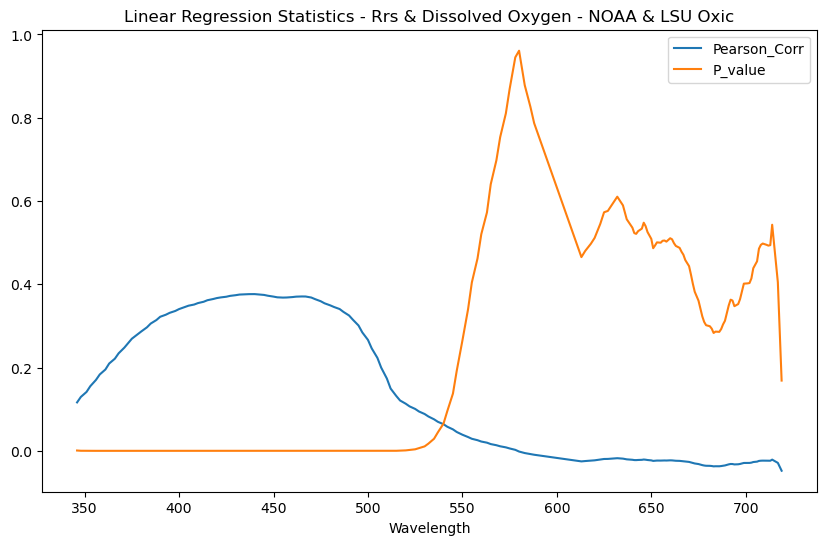

In [73]:
v_fig, v_ax = plt.subplots(figsize=(10,6))
v_ax.plot(validation_stats_df['wv'],validation_stats_df['Pearson_Corr'],label='Pearson_Corr')
v_ax.plot(validation_stats_df['wv'],validation_stats_df['P_value'],label='P_value')
v_ax.set_xlabel('Wavelength')
v_ax.set_title('Linear Regression Statistics - Rrs & Dissolved Oxygen - NOAA & LSU Oxic')
v_ax.legend(loc='best')
v_fig.savefig(f'./matchup_plots/validation_stats/NOAA+LSU_Oxic.png')
plt.show()
plt.close()